# House Prices: EDA (Exploratory Data Analysis)
This notebook focuses on understanding the data, identifying patterns, and discovering insights that will guide feature engineering and modeling decisions.

## **Key Questions to Answer:**
1. What is the distribution of SalePrice? Is it skewed?
2. Which features have the strongest correlation with SalePrice?
3. What is the pattern of missing values? (Real missing vs. absence of feature)
4. Are there outliers that might affect modeling?
5. What are the relationships between categorical features and SalePrice?

In [98]:
# Import libraries
import sys
sys.path.append('../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Taken from Deepseek src helper functions
from src.utils import (
    load_data, plot_sale_price_distribution, analyze_missing_values,
    identify_na_as_absence_columns, replace_na_with_none,
    numeric_vs_categorical_split, plot_correlation_with_target,
    plot_categorical_impact
)

# Set display options
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 50)

In [99]:
# Load data
train, test, sample = load_data("../data/")

# Create a copy for EDA (keeping original untouched)
df_train = train.copy()
df_test = test.copy()

print("\nDataset Info:")
print(f"Training set: {df_train.shape[0]} rows, {df_train.shape[1]} columns")
print(f"Test set: {df_test.shape[0]} rows, {df_test.shape[1]} columns")

Train shape: (1460, 81)
Test shape: (1459, 80)
Sample submission shape: (1459, 2)

Dataset Info:
Training set: 1460 rows, 81 columns
Test set: 1459 rows, 80 columns


## 1. Target Variable Analysis (SalePrice)

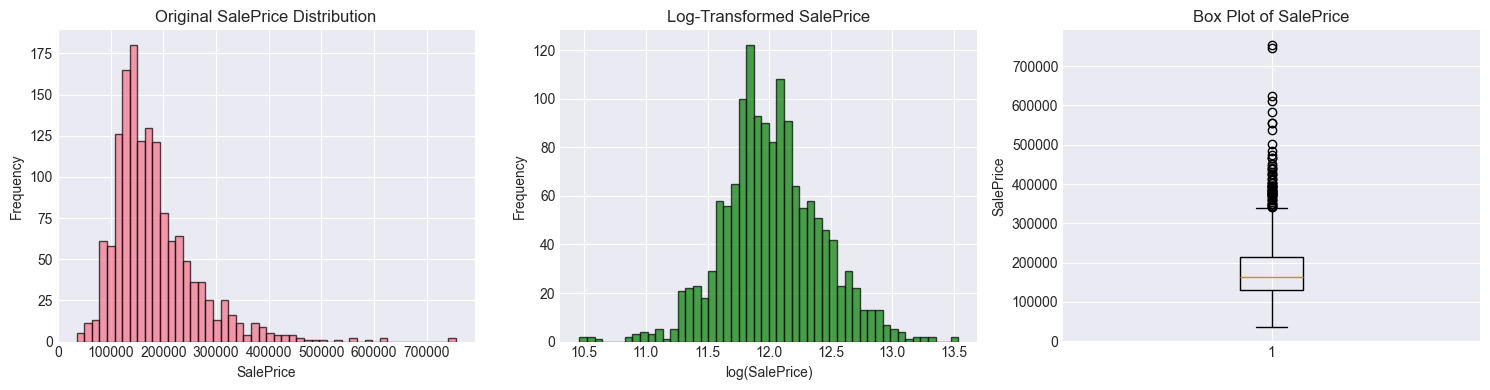

Skewness (original): 1.883
Skewness (log transformed): 0.121

SalePrice Statistics:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Number of houses with SalePrice <= 0: 0


In [100]:
# Analyze SalePrice distribution
log_prices = plot_sale_price_distribution(df_train, save_path="../reports/sale_price_distribution.png")

# Check basic statistics
print("\nSalePrice Statistics:")
print(df_train['SalePrice'].describe())

# Check for zero or negative values (should not exist for house prices)
print(f"\nNumber of houses with SalePrice <= 0: {(df_train['SalePrice'] <= 0).sum()}")

**Key Insight (Bryce):** 
1. SalePrice is right-skewed (Positive skew, Skewness: 1.883 ). Log transformation looks to have helped it normalise (Skewness 0.121)
2. No Negative house prices (Good)

## 2. Missing Values Analysis

In [101]:
# First, let's understand which NA values are actually "absence" indicators
absence_cols = identify_na_as_absence_columns()
print(f"Columns where NA means 'absence of feature':\n{absence_cols}\n")

# Check missing values BEFORE replacing NA with 'None'
print("=== Missing Values BEFORE Processing ===")
missing_before = analyze_missing_values(df_train)
print(missing_before.to_string(index=False))

Columns where NA means 'absence of feature':
['Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature']

=== Missing Values BEFORE Processing ===
      Column  Missing_Count  Missing_Percent
      PoolQC           1453        99.520548
 MiscFeature           1406        96.301370
       Alley           1369        93.767123
       Fence           1179        80.753425
  MasVnrType            872        59.726027
 FireplaceQu            690        47.260274
 LotFrontage            259        17.739726
  GarageType             81         5.547945
 GarageYrBlt             81         5.547945
GarageFinish             81         5.547945
  GarageQual             81         5.547945
  GarageCond             81         5.547945
BsmtExposure             38         2.602740
BsmtFinType2             38         2.602740
    BsmtQual             37         2.534247
    

In [102]:
# Replace NA with 'None' for absence-indicating columns (This will be treated as their own category)
df_train_clean = replace_na_with_none(df_train, absence_cols)
df_test_clean = replace_na_with_none(df_test, absence_cols)

In [103]:
# Now check missing values again
print("\n=== Missing Values AFTER Replacing NA with 'None' ===")
missing_after = analyze_missing_values(df_train_clean)
print(missing_after.to_string(index=False))


=== Missing Values AFTER Replacing NA with 'None' ===
     Column  Missing_Count  Missing_Percent
 MasVnrType            872        59.726027
LotFrontage            259        17.739726
GarageYrBlt             81         5.547945
 MasVnrArea              8         0.547945
 Electrical              1         0.068493


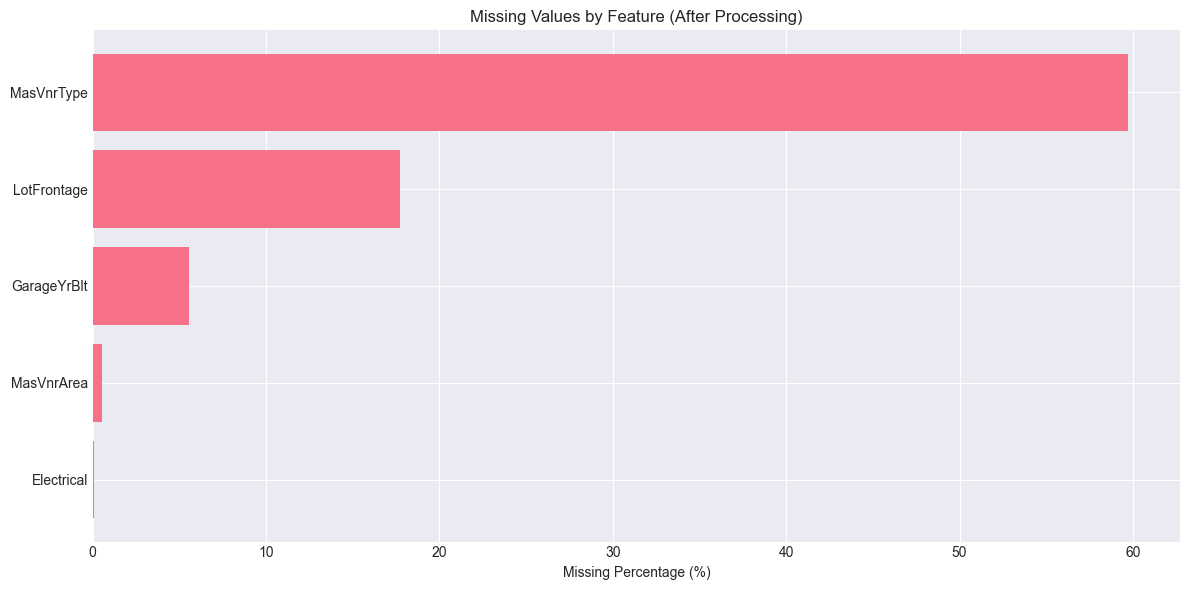

In [104]:
# Visualize missing value patterns
plt.figure(figsize=(12, 6))
missing_after_sorted = missing_after.sort_values('Missing_Percent', ascending=True)
plt.barh(missing_after_sorted['Column'], missing_after_sorted['Missing_Percent'])
plt.xlabel('Missing Percentage (%)')
plt.title('Missing Values by Feature (After Processing)')
plt.tight_layout()
plt.savefig("../reports/missing_values.png", dpi=100, bbox_inches='tight')
plt.show()

**Key Insight (Bryce):** 

After replacing NA with None on features with NA as a category, we are left with 5 features.
1. `MasVnrType` - Masonry veneer type - Categorical
2. `LotFrontage` - Linear feet of street connected to property - Variable
3. `GarageYrBlt` - Year garage was built - Variable
4. `MasVnrArea` - Masonry veneer area in square feet - Variable
5. `Electrical` - Electrical system - Categorical

These erronous leftovers need to be addressed with either removal, imputation, or assigning a new fallback category. To be addressed later...

## 3. Feature Analysis - Numerical

In [105]:
# Split into numeric and categorical
numeric_cols, categorical_cols = numeric_vs_categorical_split(df_train_clean, exclude_cols=['Id', 'SalePrice'])

print(f"Numeric features: {len(numeric_cols)}")
print(f"Categorical features: {len(categorical_cols)}")
print(f"\nFirst 10 numeric features: {numeric_cols[:10]}")
print(f"\nFirst 10 categorical features: {categorical_cols[:10]}")

Numeric features: 36
Categorical features: 43

First 10 numeric features: ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2']

First 10 categorical features: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1']


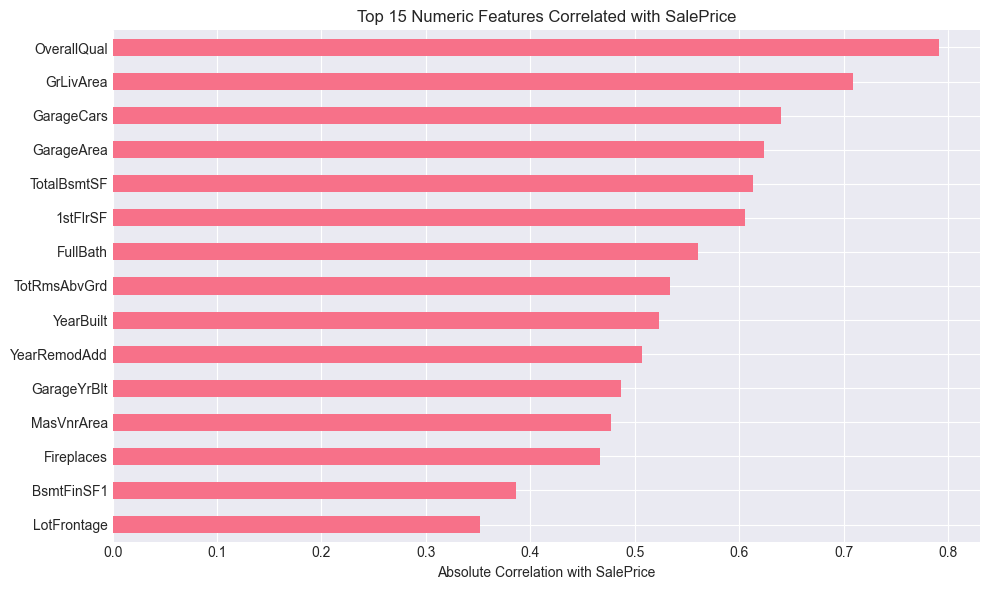


Top 10 features correlated with SalePrice:
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101


In [106]:
# Correlation analysis with SalePrice
top_correlations = plot_correlation_with_target(df_train_clean, top_n=15, save_path="../reports/top_correlations.png")
print("\nTop 10 features correlated with SalePrice:")
print(top_correlations.head(10).to_string())

**Key Insight (Bryce):** 

The three most important features (`OverallQual`, `GrLivArea`, `GarageCars`) relate to the overall material quality, above ground living area, and size of garage. We should expect these features to be present as the main weights in our models.

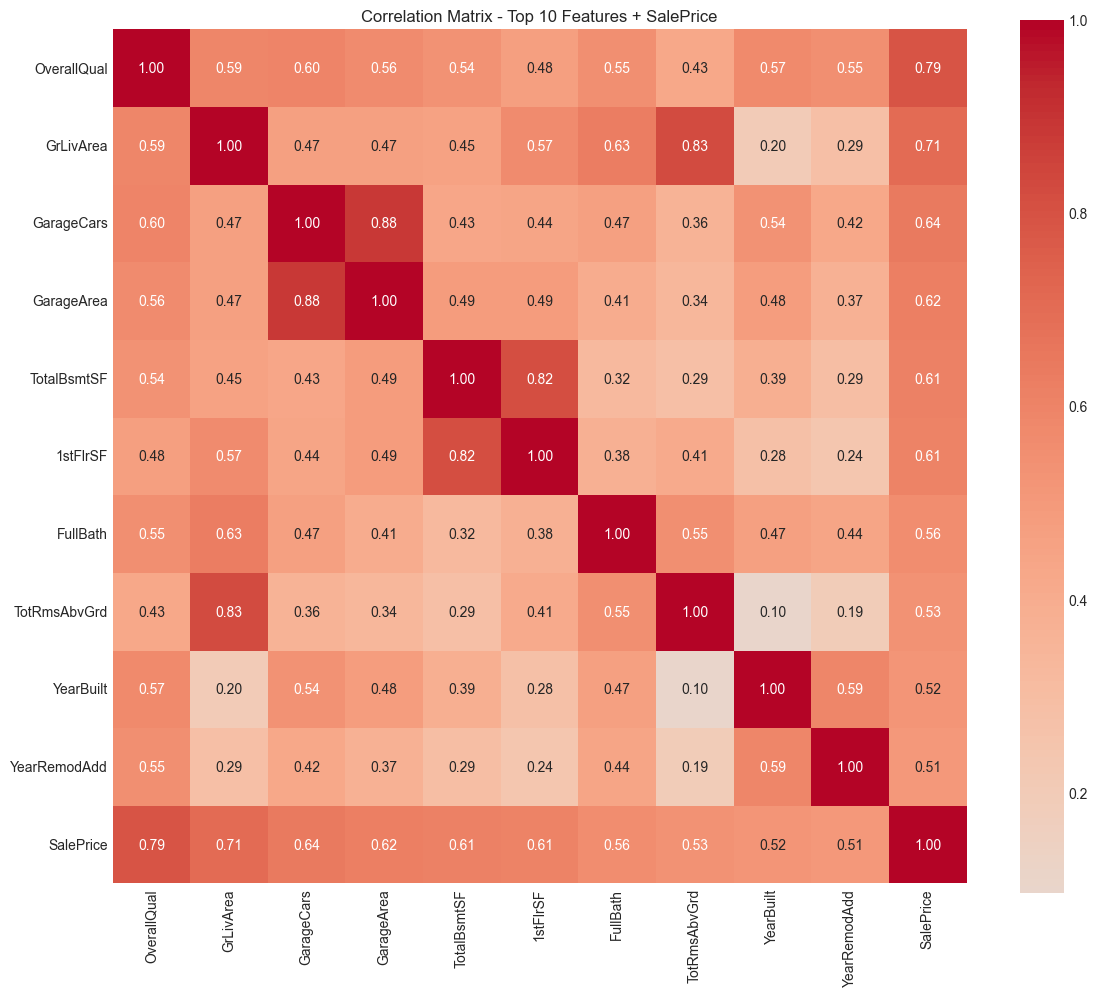

In [107]:
# Check for multicollinearity among top features
top_features = top_correlations.head(10).index.tolist()
correlation_matrix = df_train_clean[top_features + ['SalePrice']].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix - Top 10 Features + SalePrice')
plt.tight_layout()
plt.savefig("../reports/correlation_matrix.png", dpi=100, bbox_inches='tight')
plt.show()

**Key Insight (DeepSeek):** 

High correlations between `GrLivArea` and `TotRmsAbvGrd` (0.83), `GarageCars` and `GarageArea` (0.88). We might want to combine these or use one to reduce multicollinearity.

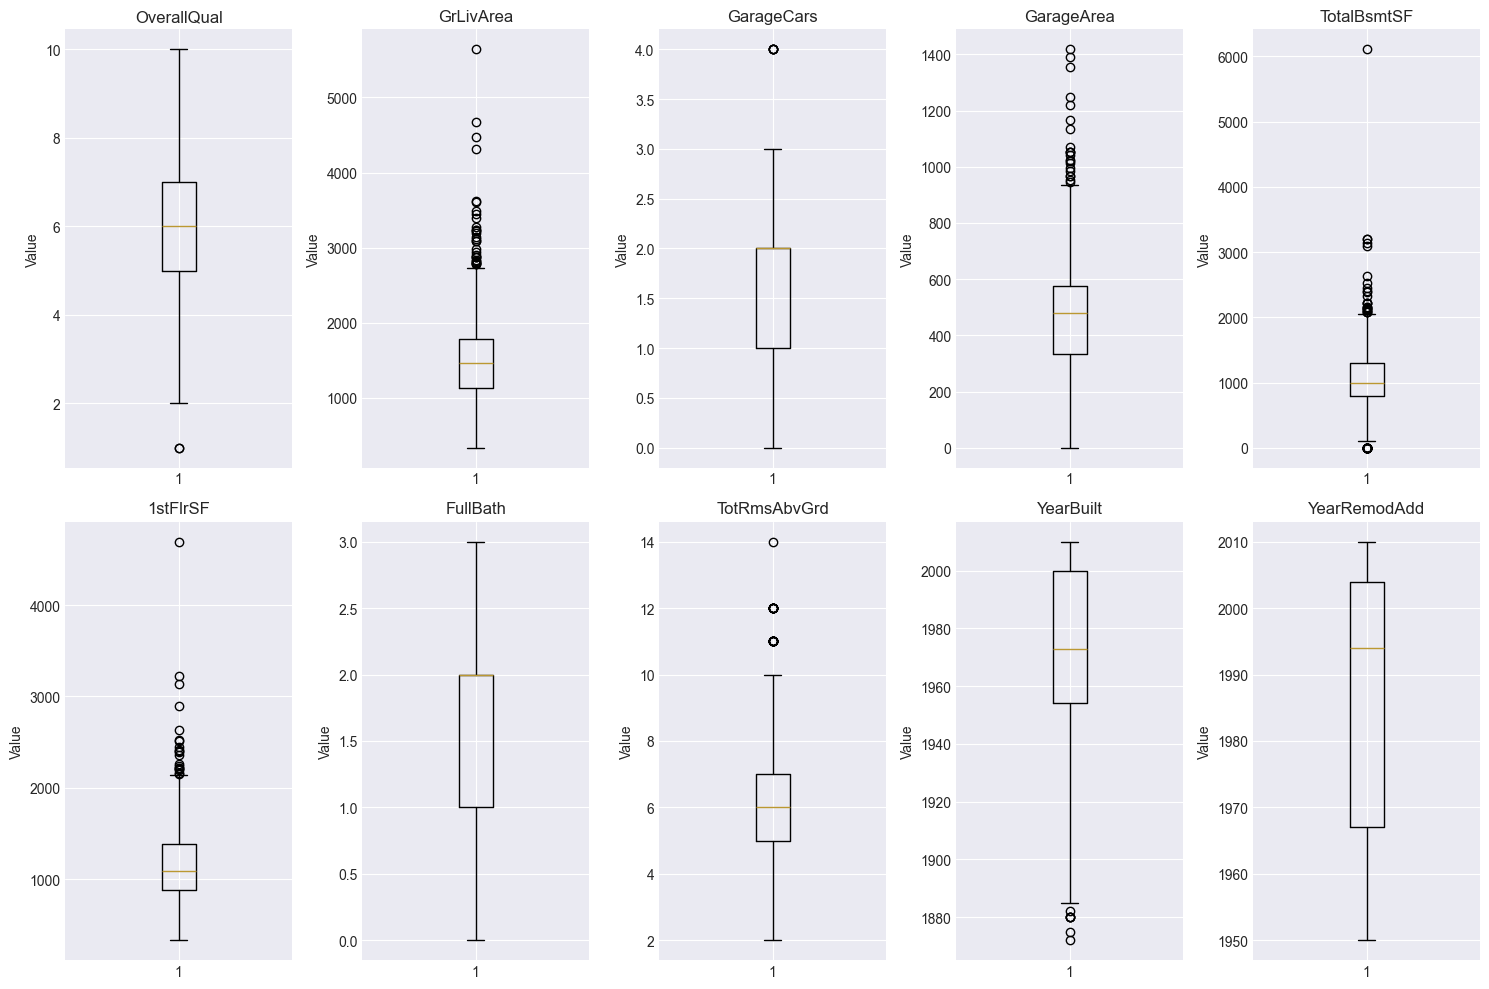

In [108]:
# Check for outliers in important numeric features
# Note: Added top 10 features by correlation to SalePrice
important_features = ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd']

fig, axes = plt.subplots(2, 5, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(important_features):
    axes[idx].boxplot(df_train_clean[feature])
    axes[idx].set_title(feature)
    axes[idx].set_ylabel('Value')

# Remove empty subplot
## axes[ ].set_visible(False)

plt.tight_layout()
plt.savefig("../reports/outliers_boxplots.png", dpi=100, bbox_inches='tight')
plt.show()

In [109]:
# Check extreme values in GrLivArea and SalePrice
extreme_living = df_train_clean[df_train_clean['GrLivArea'] > 4000]
print(f"Houses with > 4000 sq ft living area: {len(extreme_living)}")
if len(extreme_living) > 0:
    print(extreme_living[['Id', 'GrLivArea', 'SalePrice', 'OverallQual']])

Houses with > 4000 sq ft living area: 4
        Id  GrLivArea  SalePrice  OverallQual
523    524       4676     184750           10
691    692       4316     755000           10
1182  1183       4476     745000           10
1298  1299       5642     160000           10


**Key Insight (DeepSeek):** 

There are a few houses with very large living area but low sale price relative to size. These might be outliers to investigate.

In [110]:
# Check extreme values in TotalBsmtSF and SalePrice
extreme_basement = df_train_clean[df_train_clean['TotalBsmtSF'] > 3000]
print(f"Houses with > 3000 sq ft basement area: {len(extreme_basement)}")
if len(extreme_basement) > 0:
    print(extreme_basement[['Id', 'TotalBsmtSF', 'SalePrice', 'OverallQual']])

Houses with > 3000 sq ft basement area: 5
        Id  TotalBsmtSF  SalePrice  OverallQual
332    333         3206     284000            8
440    441         3094     555000           10
496    497         3200     430000            8
523    524         3138     184750           10
1298  1299         6110     160000           10


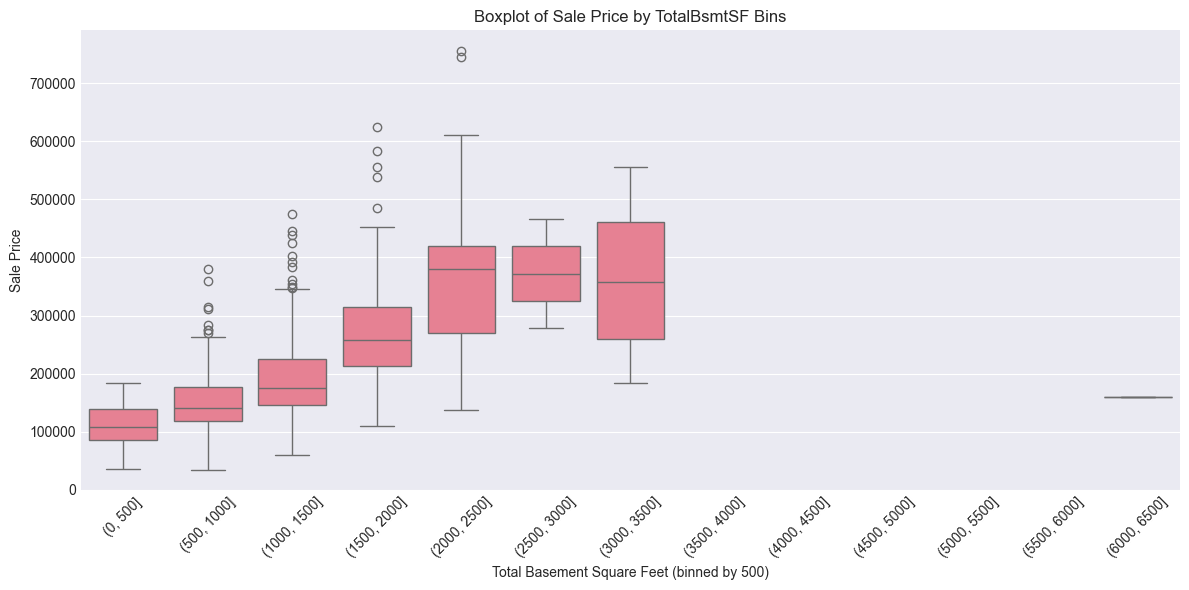

In [111]:
# Create a copy of the DataFrame
df_plot = df_train_clean.copy()

# Create bins for TotalBsmtSF in increments of 500
# Adjust max_bin based on your data's maximum value
max_value = df_train_clean['TotalBsmtSF'].max()
bins = range(0, int(max_value) + 500, 500)  # 0, 500, 1000, 1500, ...

# Add the bin column to the copy
df_plot['BsmtBin'] = pd.cut(df_plot['TotalBsmtSF'], bins=bins)

# Create the boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x='BsmtBin', y='SalePrice', data=df_plot)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Add labels and title
plt.xlabel('Total Basement Square Feet (binned by 500)')
plt.ylabel('Sale Price')
plt.title('Boxplot of Sale Price by TotalBsmtSF Bins')

plt.tight_layout()
plt.savefig("../reports/outliers_boxplots_binned_TotalBsmtSF.png", dpi=100, bbox_inches='tight')
plt.show()

**Key Insight (Bryce):** 

There are a few houses with very large basement area but not necessarily high SalePrice. These might be outliers to investigate.

## 4. Feature Analysis - Categorical

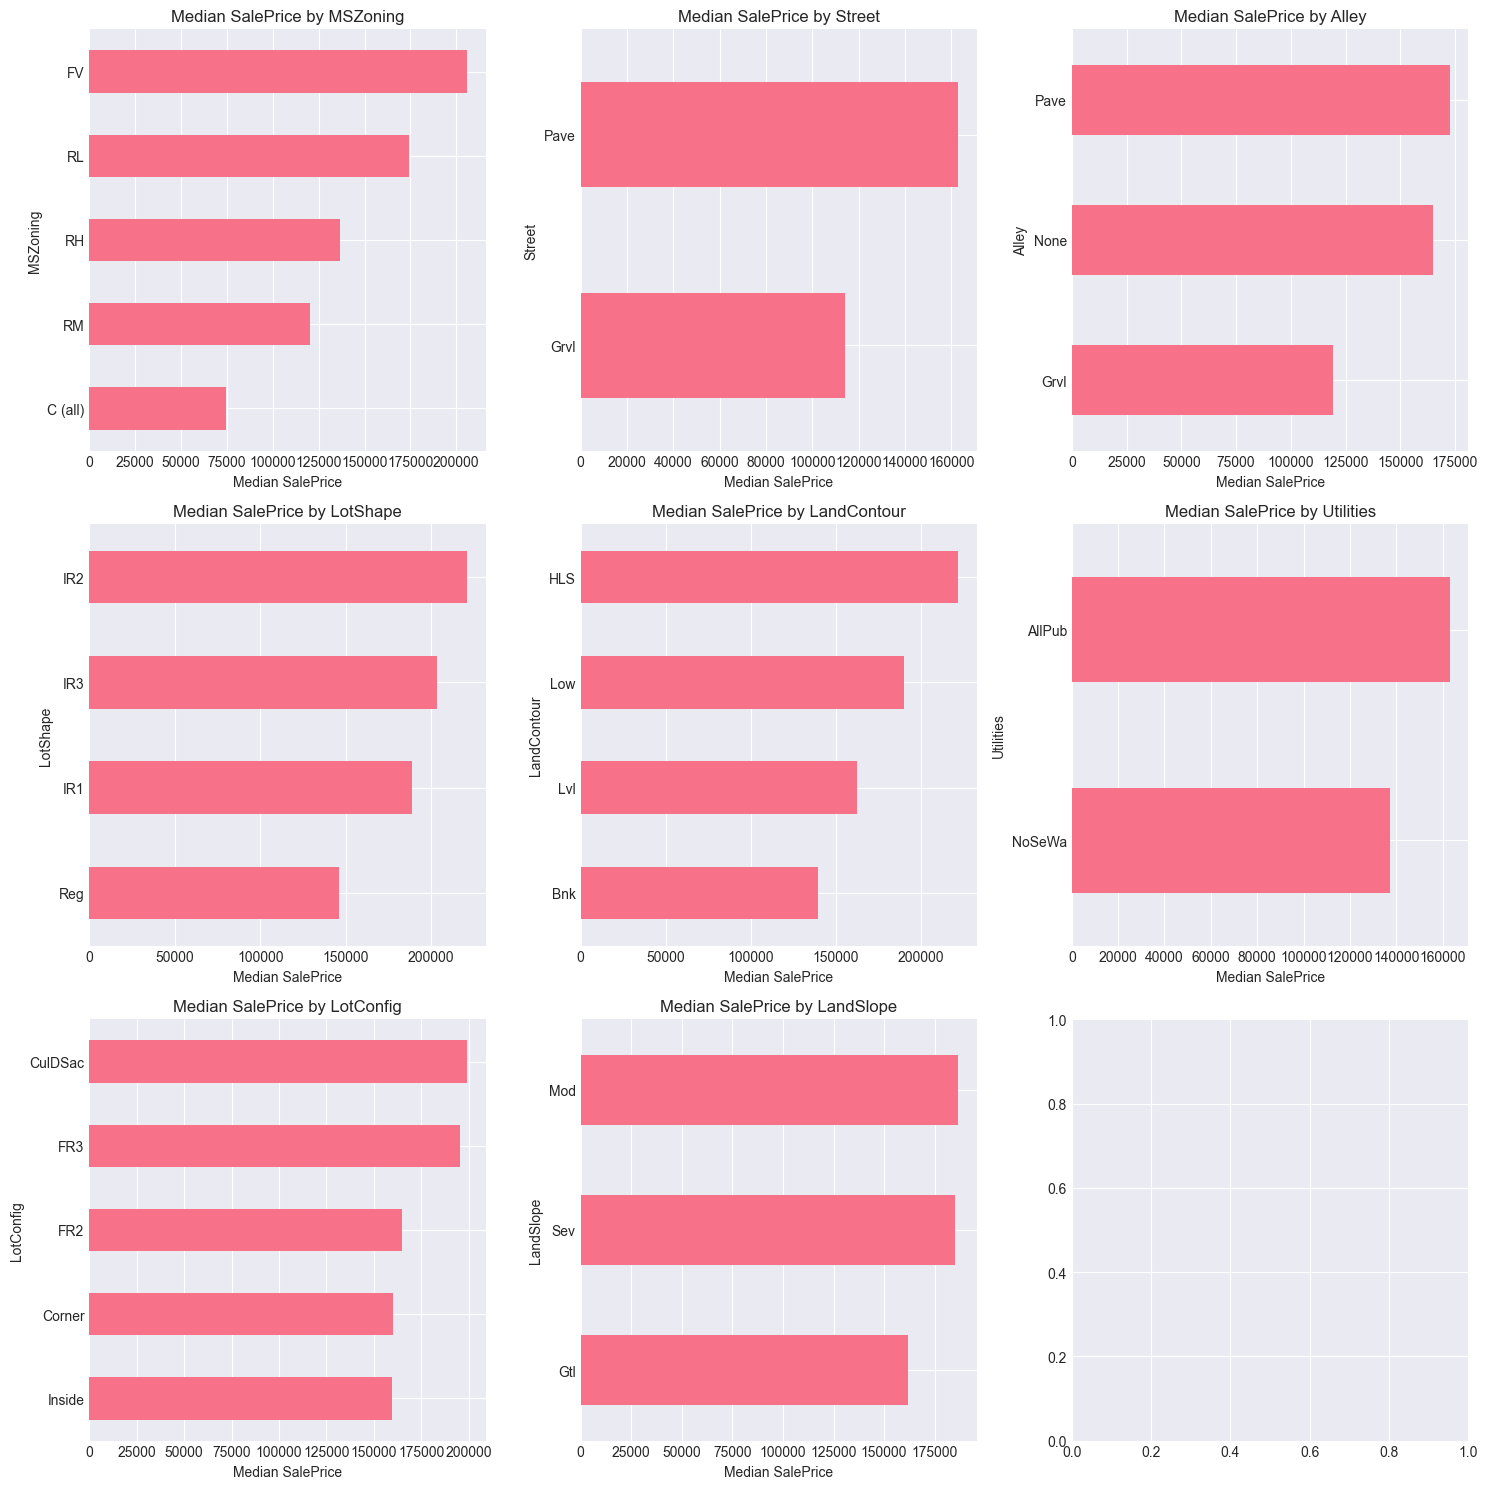

In [112]:
# Analyze categorical features impact
plot_categorical_impact(df_train_clean, categorical_cols[:9], max_categories=10, save_path="../reports/categorical_impact.png")

In [113]:
# Check cardinality of categorical features
cardinality = {}
for col in categorical_cols:
    cardinality[col] = df_train_clean[col].nunique()

cardinality_df = pd.DataFrame(cardinality.items(), columns=['Feature', 'Unique_Values'])
cardinality_df = cardinality_df.sort_values('Unique_Values', ascending=False)

print("Categorical feature cardinality:")
print(cardinality_df.to_string(index=False))

Categorical feature cardinality:
      Feature  Unique_Values
 Neighborhood             25
  Exterior2nd             16
  Exterior1st             15
   Condition1              9
     SaleType              9
   HouseStyle              8
     RoofMatl              8
   Condition2              8
 BsmtFinType2              7
 BsmtFinType1              7
   GarageType              7
   Functional              7
      Heating              6
SaleCondition              6
   GarageCond              6
  FireplaceQu              6
   GarageQual              6
    RoofStyle              6
   Foundation              6
  MiscFeature              5
        Fence              5
 BsmtExposure              5
    ExterCond              5
     BsmtQual              5
     BldgType              5
    LotConfig              5
     MSZoning              5
   Electrical              5
    HeatingQC              5
     BsmtCond              5
    ExterQual              4
  LandContour              4
     LotSh

**Key Insight (DeepSeek):** 

`Neighborhood` has 25 unique values - high cardinality. One-hot encoding would create many sparse columns. Consider target encoding or using it as a grouping feature.

## 5. Temporal Features Analysis

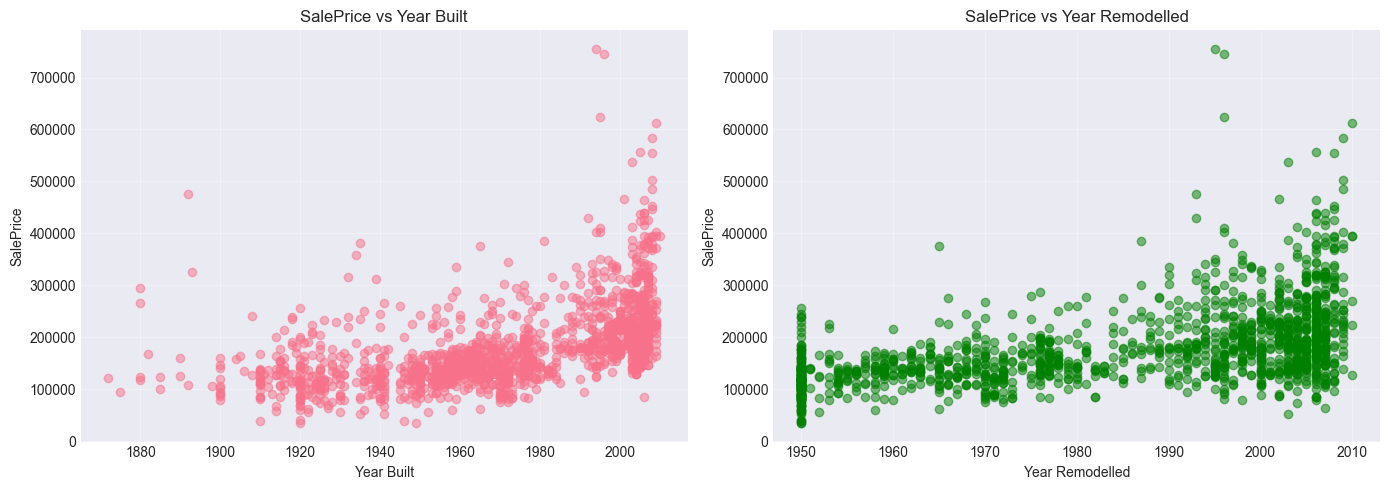

In [114]:
# Analyze YearBuilt and YearRemodAdd
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# YearBuilt vs SalePrice
axes[0].scatter(df_train_clean['YearBuilt'], df_train_clean['SalePrice'], alpha=0.5)
axes[0].set_xlabel('Year Built')
axes[0].set_ylabel('SalePrice')
axes[0].set_title('SalePrice vs Year Built')
axes[0].grid(True, alpha=0.3)

# YearRemodAdd vs SalePrice
axes[1].scatter(df_train_clean['YearRemodAdd'], df_train_clean['SalePrice'], alpha=0.5, color='green')
axes[1].set_xlabel('Year Remodelled')
axes[1].set_ylabel('SalePrice')
axes[1].set_title('SalePrice vs Year Remodelled')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../reports/temporal_features.png", dpi=100, bbox_inches='tight')
plt.show()

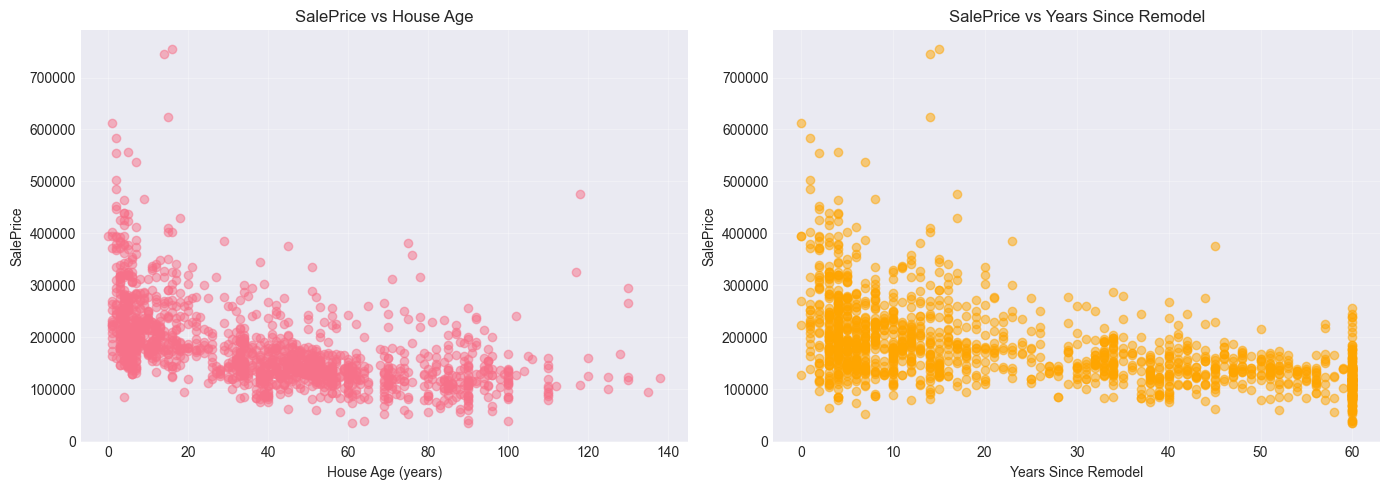

In [115]:
# Create age features for EDA
df_train_clean['HouseAge'] = 2010 - df_train_clean['YearBuilt']  # 2010 is last year in dataset
df_train_clean['RemodAge'] = 2010 - df_train_clean['YearRemodAdd']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_train_clean['HouseAge'], df_train_clean['SalePrice'], alpha=0.5)
axes[0].set_xlabel('House Age (years)')
axes[0].set_ylabel('SalePrice')
axes[0].set_title('SalePrice vs House Age')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(df_train_clean['RemodAge'], df_train_clean['SalePrice'], alpha=0.5, color='orange')
axes[1].set_xlabel('Years Since Remodel')
axes[1].set_ylabel('SalePrice')
axes[1].set_title('SalePrice vs Years Since Remodel')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Key Insight (Bryce):** 

There seems to be a cutoff year for `YearRemodAdd`. No houses were remodelled before 1950. This information should be put to use in a separate categorical column.

**Key Insight (DeepSeek):** 

Newer houses and recently remodelled houses tend to have higher prices. Age features will be valuable.

## 6. Neighborhood Analysis

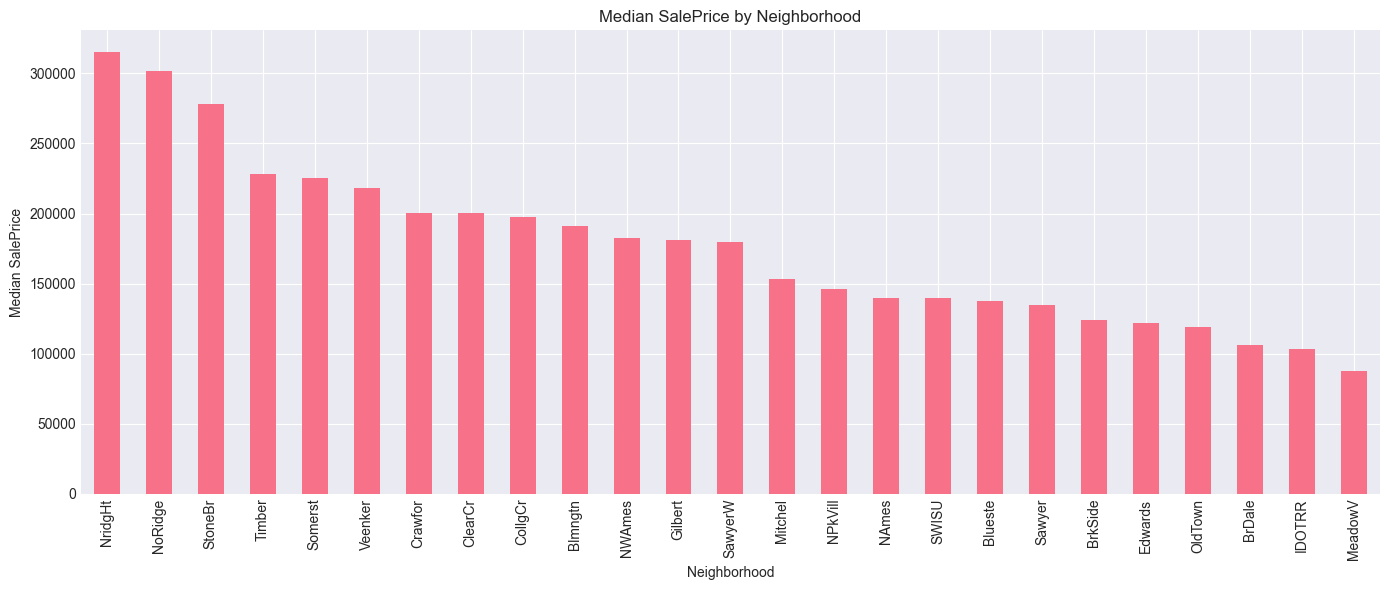

Top 5 most expensive neighborhoods:
                median           mean  count
Neighborhood                                
NridgHt       315000.0  316270.623377     77
NoRidge       301500.0  335295.317073     41
StoneBr       278000.0  310499.000000     25
Timber        228475.0  242247.447368     38
Somerst       225500.0  225379.837209     86

Bottom 5 neighborhoods:
                median           mean  count
Neighborhood                                
Edwards       121750.0  128219.700000    100
OldTown       119000.0  128225.300885    113
BrDale        106000.0  104493.750000     16
IDOTRR        103000.0  100123.783784     37
MeadowV        88000.0   98576.470588     17


In [117]:
# Neighborhood price distribution
neighborhood_prices = df_train_clean.groupby('Neighborhood')['SalePrice'].agg(['median', 'mean', 'count'])
neighborhood_prices = neighborhood_prices.sort_values('median', ascending=False)

plt.figure(figsize=(14, 6))
neighborhood_prices['median'].plot(kind='bar')
plt.xlabel('Neighborhood')
plt.ylabel('Median SalePrice')
plt.title('Median SalePrice by Neighborhood')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("../reports/neighborhood_prices.png", dpi=100, bbox_inches='tight')
plt.show()

print("Top 5 most expensive neighborhoods:")
print(neighborhood_prices.head(5))
print("\nBottom 5 neighborhoods:")
print(neighborhood_prices.tail(5))

**Key Insight (DeepSeek):** 

Huge variation in prices by neighborhood (from ~$60k to ~$300k median). This will be very important for modeling.


## 7. Summary & Key Insights for Modeling

In [118]:
summary = {
    'Finding': [
        'SalePrice is right-skewed (skewness > 0)',
        'OverallQual is strongest predictor (r=0.79)',
        'Missing values in 14 columns are actually "absence" indicators',
        'GrLivArea and TotRmsAbvGrd are highly correlated (0.83)',
        'GarageCars and GarageArea are highly correlated (0.88)',
        'Neighborhood has 25 unique values - high cardinality',
        'House age and remodel age show clear price trends',
        'Several outliers exist (very large houses with low prices)'
    ],
    'Impact on Modeling': [
        'Use log transformation of SalePrice',
        'Will be most important feature in models',
        'Replace with "None" before encoding',
        'Consider combining or selecting one to reduce multicollinearity',
        'Consider combining or selecting one to reduce multicollinearity',
        'Consider target encoding instead of one-hot',
        'Create age features from YearBuilt and YearRemodAdd',
        'Consider capping or removing extreme outliers'
    ]
}

summary_df = pd.DataFrame(summary)
print("=== EDA Summary & Modeling Recommendations ===\n")
print(summary_df.to_string(index=False))

=== EDA Summary & Modeling Recommendations ===

                                                       Finding                                              Impact on Modeling
                      SalePrice is right-skewed (skewness > 0)                             Use log transformation of SalePrice
                   OverallQual is strongest predictor (r=0.79)                        Will be most important feature in models
Missing values in 14 columns are actually "absence" indicators                             Replace with "None" before encoding
       GrLivArea and TotRmsAbvGrd are highly correlated (0.83) Consider combining or selecting one to reduce multicollinearity
        GarageCars and GarageArea are highly correlated (0.88) Consider combining or selecting one to reduce multicollinearity
          Neighborhood has 25 unique values - high cardinality                     Consider target encoding instead of one-hot
             House age and remodel age show clear price trends 